In [2]:
import pymysql
import pandas as pd

# connect directly using pymysql
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='Tanmayee@1708',  
    database='employee_data'
)

# import all 3 tables
general_data = pd.read_sql('SELECT * FROM general_data', conn)
employee_survey = pd.read_sql('SELECT * FROM employee_survey_data', conn)
manager_survey = pd.read_sql('SELECT * FROM manager_survey_data', conn)
attendance_attrition = pd.read_sql("""
    SELECT 
        EmployeeID,
        avg_hours_worked,
        workload_category
    FROM attendance_attrition
""", conn)

print("General data:", general_data.shape)
print("Employee survey:", employee_survey.shape)
print("Manager survey:", manager_survey.shape)
print("Attendence Attrition:", attendance_attrition.shape)

df = general_data.merge(
    employee_survey, on='EmployeeID', how='left'
).merge(
    manager_survey, on='EmployeeID', how='left'
).merge(
    attendance_attrition, on='EmployeeID', how='left'
)

print("Merged:", df.shape)
print(df.columns.tolist())

C:\Users\Sree Tanmayee\AppData\Local\Temp\ipykernel_23212\1787713193.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  general_data = pd.read_sql('SELECT * FROM general_data', conn)
C:\Users\Sree Tanmayee\AppData\Local\Temp\ipykernel_23212\1787713193.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  employee_survey = pd.read_sql('SELECT * FROM employee_survey_data', conn)
C:\Users\Sree Tanmayee\AppData\Local\Temp\ipykernel_23212\1787713193.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  manager_survey = pd.read_s

General data: (4382, 24)
Employee survey: (4410, 4)
Manager survey: (4410, 3)
Attendence Attrition: (4382, 3)
Merged: (4382, 31)
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked', 'workload_category']


In [3]:
# check missing values
print("Missing values:")
print(df.isnull().sum())

# check data types
print("\nData types:")
print(df.dtypes)

# check attrition distribution
print("\nAttrition distribution:")
print(df['Attrition'].value_counts())

# check for any constant columns
print("\nConstant columns:")
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "→ only one unique value — drop this")

Missing values:
Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
JobInvolvement             0
PerformanceRating          0
avg_hours_worked           0
workload_category          0
dtype: int64

Data types:
Age                          int64
Attrition               

In [4]:
df = df.drop(columns=[
    'EmployeeCount',   
    'Over18',          
    'StandardHours',   
    
])
print( df.shape)
print( df.columns.tolist())
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

(4382, 28)
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked', 'workload_category']
Attrition
No     3677
Yes     705
Name: count, dtype: int64
Attrition
No     83.911456
Yes    16.088544
Name: proportion, dtype: float64


In [5]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# encode workload_category
df = pd.get_dummies(df, columns=['workload_category'])

print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked', 'workload_category_Normal', 'workload_category_Overworked', 'workload_category_Underworked']


In [7]:
X = df[[
    'MonthlyIncome',
    'YearsSinceLastPromotion',
    'YearsAtCompany',
    'JobSatisfaction',
    'JobInvolvement',
    'DistanceFromHome',
    'Age',
    'avg_hours_worked'    
]]

y = df['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Attrition distribution:\n", y.value_counts())

# Step 2 — split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train 20% test
    random_state=42,    # reproducible results
    stratify=y          # maintain attrition ratio in both sets
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# Step 3 — scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ─────────────────────────────────────────
# MODEL 1 — Logistic Regression
# ─────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,      # enough iterations to converge
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n─── Logistic Regression Results ───")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("AUC-ROC:", round(roc_auc_score(y_test, lr_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


Features shape: (4382, 8)
Target shape: (4382,)
Attrition distribution:
 Attrition
No     3677
Yes     705
Name: count, dtype: int64

Train size: (3505, 8)
Test size: (877, 8)

─── Logistic Regression Results ───
Accuracy: 84.49 %
AUC-ROC: 0.7192

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.99      0.91       736
         Yes       0.63      0.09      0.15       141

    accuracy                           0.84       877
   macro avg       0.74      0.54      0.53       877
weighted avg       0.81      0.84      0.79       877




─── Random Forest Results ───
Accuracy: 99.32 %
AUC-ROC: 0.9997

Classification Report:
              precision    recall  f1-score   support

          No       0.99      1.00      1.00       736
         Yes       1.00      0.96      0.98       141

    accuracy                           0.99       877
   macro avg       1.00      0.98      0.99       877
weighted avg       0.99      0.99      0.99       877


─── Model Comparison ───
Logistic Regression → Accuracy: 84.49% | AUC: 0.7192
Random Forest       → Accuracy: 99.32% | AUC: 0.9997


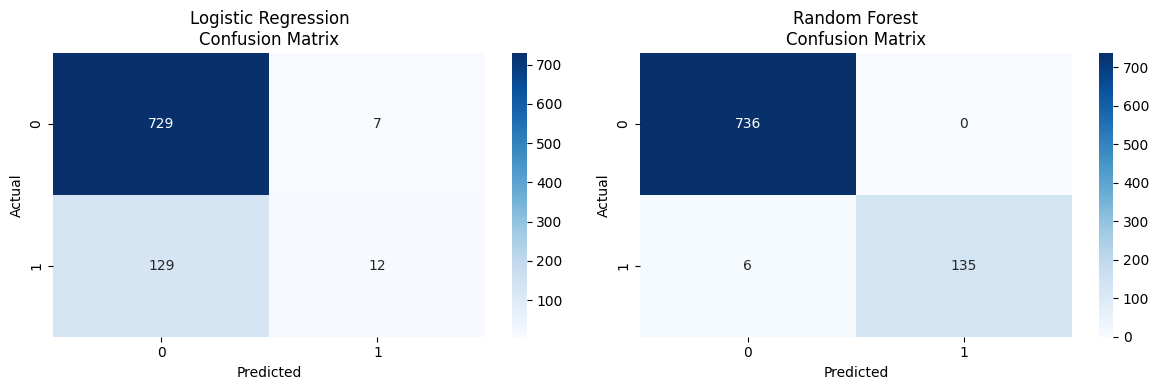

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)
rf_model.fit(X_train, y_train)  # no scaling needed for RF
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("\n─── Random Forest Results ───")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print("AUC-ROC:", round(roc_auc_score(y_test, rf_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# ─────────────────────────────────────────
# COMPARE BOTH MODELS
# ─────────────────────────────────────────
print("\n─── Model Comparison ───")
print(f"Logistic Regression → Accuracy: {round(accuracy_score(y_test, lr_pred)*100,2)}% | AUC: {round(roc_auc_score(y_test, lr_prob),4)}")
print(f"Random Forest       → Accuracy: {round(accuracy_score(y_test, rf_pred)*100,2)}% | AUC: {round(roc_auc_score(y_test, rf_prob),4)}")

# ─────────────────────────────────────────
# CONFUSION MATRIX FOR BOTH
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred), 
            annot=True, fmt='d', ax=axes[0],
            cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), 
            annot=True, fmt='d', ax=axes[1],
            cmap='Blues')
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [9]:

# check training accuracy vs test accuracy
rf_train_pred = rf_model.predict(X_train)
print("RF Train Accuracy:", round(accuracy_score(y_train, rf_train_pred)*100,2))
print("RF Test Accuracy:", round(accuracy_score(y_test, rf_pred)*100,2))

RF Train Accuracy: 100.0
RF Test Accuracy: 99.32


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          
    min_samples_split=10, 
    min_samples_leaf=5,   
    max_features='sqrt',  
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# check overfitting again
rf_train_pred = rf_model.predict(X_train)
print("Train Accuracy:", round(accuracy_score(y_train, rf_train_pred)*100,2))
print("Test Accuracy:", round(accuracy_score(y_test, rf_pred)*100,2))
print("AUC:", round(roc_auc_score(y_test, rf_prob),4))

Train Accuracy: 82.97
Test Accuracy: 78.45
AUC: 0.8322


In [11]:
# check what values attrition has now
print(df['Attrition'].value_counts())
print(df['Attrition'].dtype)

Attrition
No     3677
Yes     705
Name: count, dtype: int64
object


In [12]:
# filter current employees (Attrition = 0 means still working)
current_employees = df[df['Attrition'] == 0].copy()
print("Current employees:", len(current_employees))

Current employees: 0


In [13]:
# check unique values
print(df['Attrition'].unique())

['No' 'Yes']


In [14]:
current_employees = df[df['Attrition'] == 'No'].copy()
print("Current employees:", len(current_employees))

Current employees: 3677


In [15]:
# get exact columns model was trained on
model_columns = X_train.columns.tolist()

# use only model columns
X_current = current_employees[model_columns]

# predict probability
current_employees['attrition_probability'] = \
    rf_model.predict_proba(X_current)[:,1]

# convert to 1-10 risk score
current_employees['risk_score'] = \
    (current_employees['attrition_probability'] * 10).round(1)
current_employees['risk_score'] = \
    current_employees['risk_score'].clip(1, 10)

# add risk label
current_employees['risk_label'] = pd.cut(
    current_employees['risk_score'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Safe', 'Low', 'Medium', 'High', 'Critical']
)

# show results
print(current_employees[[
    'EmployeeID',
    'Department',
    'attrition_probability',
    'risk_score',
    'risk_label'
]].head(10))

print("\nRisk distribution:")
print(current_employees['risk_label'].value_counts())

    EmployeeID              Department  attrition_probability  risk_score  \
0            1                   Sales               0.296785         3.0   
2            3  Research & Development               0.327225         3.3   
3            4  Research & Development               0.210468         2.1   
4            5  Research & Development               0.475451         4.8   
5            6  Research & Development               0.518696         5.2   
7            8  Research & Development               0.673909         6.7   
8            9  Research & Development               0.313774         3.1   
9           10  Research & Development               0.397104         4.0   
10          11  Research & Development               0.299500         3.0   
11          12  Research & Development               0.176640         1.8   

   risk_label  
0         Low  
2         Low  
3         Low  
4      Medium  
5      Medium  
7        High  
8         Low  
9         Low  
10      

In [16]:
print(current_employees['risk_label'].value_counts())
print("\nBy Department:")
print(current_employees.groupby(
    ['Department','risk_label'])['EmployeeID'].count())

risk_label
Low         2495
Medium       826
High         253
Safe         100
Critical       3
Name: count, dtype: int64

By Department:
Department              risk_label
Human Resources         Safe             3
                        Low             82
                        Medium          35
                        High            12
                        Critical         0
Research & Development  Safe            55
                        Low           1678
                        Medium         502
                        High           178
                        Critical         3
Sales                   Safe            42
                        Low            735
                        Medium         289
                        High            63
                        Critical         0
Name: EmployeeID, dtype: int64


C:\Users\Sree Tanmayee\AppData\Local\Temp\ipykernel_23212\2820960916.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(current_employees.groupby(


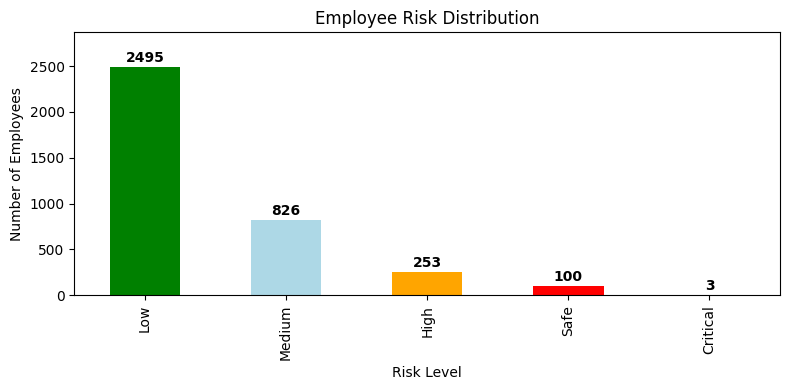

PDF saved successfully!


In [22]:
from fpdf import FPDF
import matplotlib.pyplot as plt

# install if needed
# !pip install fpdf2
high_risk = current_employees[
    current_employees['risk_label'].isin(['High', 'Critical'])
][[
    'EmployeeID',
    'Department',
    'risk_score',
    'risk_label',
    'attrition_probability'
]].sort_values('risk_score', ascending=False)

# create chart first
fig, ax = plt.subplots(figsize=(8, 4))
current_employees['risk_label'].value_counts().plot(
    kind='bar', 
    color=['green','lightblue','orange','red','darkred'],
    ax=ax
)
ax.set_title('Employee Risk Distribution')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Employees')
plt.tight_layout()
# add data labels on bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# set minimum y axis so Critical bar is visible
ax.set_ylim(0, max(current_employees['risk_label'].value_counts()) * 1.15)

plt.tight_layout()
plt.savefig('risk_chart.png')
plt.show()

# create PDF
pdf = FPDF()
pdf.add_page()

# title
pdf.set_font('Arial', 'B', 16)
pdf.cell(0, 10, 'Employee Attrition Risk Report', ln=True, align='C')
pdf.ln(5)

# date
pdf.set_font('Arial', '', 10)
pdf.cell(0, 8, f'Generated on: {pd.Timestamp.now().strftime("%Y-%m-%d")}', ln=True)
pdf.ln(5)

# summary section
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 8, 'Executive Summary', ln=True)
pdf.set_font('Arial', '', 10)
pdf.cell(0, 7, f'Total current employees analysed: {len(current_employees)}', ln=True)
pdf.cell(0, 7, f'High risk employees: {len(current_employees[current_employees["risk_label"]=="High"])}', ln=True)
pdf.cell(0, 7, f'Critical risk employees: {len(current_employees[current_employees["risk_label"]=="Critical"])}', ln=True)
pdf.ln(5)

# risk chart
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 8, 'Risk Distribution Chart', ln=True)
pdf.image('risk_chart.png', w=180)
pdf.ln(5)

# high risk employees table
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 8, 'High Risk Employees', ln=True)
pdf.set_font('Arial', 'B', 9)
pdf.cell(30, 7, 'EmployeeID', border=1)
pdf.cell(70, 7, 'Department', border=1)
pdf.cell(30, 7, 'Risk Score', border=1)
pdf.cell(40, 7, 'Risk Label', border=1, ln=True)

pdf.set_font('Arial', '', 9)
for _, row in high_risk.head(20).iterrows():
    pdf.cell(30, 7, str(row['EmployeeID']), border=1)
    pdf.cell(70, 7, str(row['Department']), border=1)
    pdf.cell(30, 7, str(row['risk_score']), border=1)
    pdf.cell(40, 7, str(row['risk_label']), border=1, ln=True)

# save PDF
pdf.output('attrition_risk_report.pdf')
print("PDF saved successfully!")

In [21]:
import os
print(os.getcwd())

c:\Users\Sree Tanmayee\OneDrive\Desktop\EGA_det
